# Model A baseline — FMA acoustic embeddings

Interpretation of the Track A baseline. Pipeline code lives in `aux/`; the sweep that
produced the published numbers is `python -m aux.experiments.sweeps`. This notebook asks
*what the embedding space actually looks like* and why the chosen configuration won.

Configuration: FMA small (8,000 tracks, 8 balanced genres), 518 precomputed features →
standardize → PCA(128, whiten) → cosine.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from aux.models.acoustic import build_embeddings, load_subset

features, labels = load_subset("small")
genres = labels["genre"]
X = build_embeddings(features)

print(f"{features.shape[0]:,} tracks | {features.shape[1]} raw features -> {X.shape[1]} dims")
print(f"{len(np.unique(genres))} genres: {', '.join(sorted(np.unique(genres)))}")

8,000 tracks | 518 raw features -> 128 dims
8 genres: Electronic, Experimental, Folk, Hip-Hop, Instrumental, International, Pop, Rock


## 1. How concentrated is the variance?

The reason whitening matters at all. If variance is heavily front-loaded, an unwhitened
Euclidean distance is decided by a handful of components no matter how many we keep.

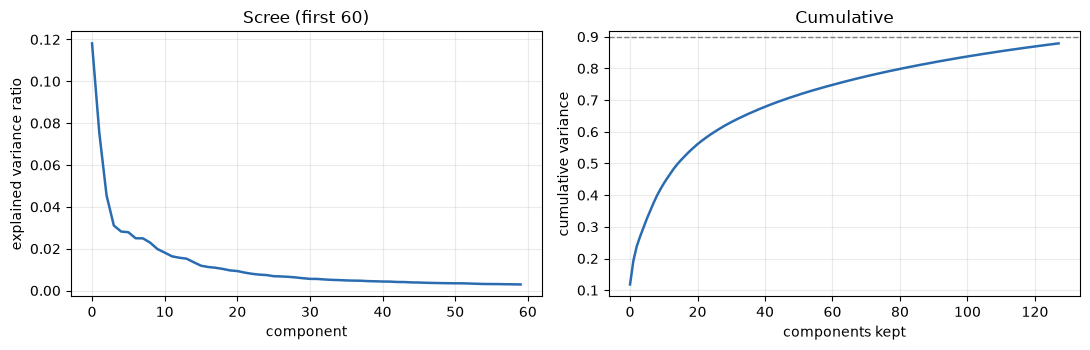

component 1 alone: 11.8%
ratio of 1st to 128th component variance: 88x


In [2]:
scaled = StandardScaler().fit_transform(features.to_numpy())
pca = PCA(n_components=128, random_state=0).fit(scaled)
ratio = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(ratio[:60], lw=1.8, color="#2b6cb0")
axes[0].set(xlabel="component", ylabel="explained variance ratio", title="Scree (first 60)")
axes[1].plot(np.cumsum(ratio), lw=1.8, color="#2b6cb0")
axes[1].axhline(0.9, ls="--", c="grey", lw=1)
axes[1].set(xlabel="components kept", ylabel="cumulative variance", title="Cumulative")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"component 1 alone: {ratio[0]:.1%}")
print(f"ratio of 1st to 128th component variance: {ratio[0] / ratio[127]:.0f}x")

**Component 1 carries far more variance than the tail.** With that spread, an
unwhitened Euclidean distance is dominated by the leading components — nominally 128
dimensions, effectively a handful. That is the defect whitening addresses, and
`tests/test_acoustic.py::test_whitening_equalizes_component_variance` pins it down.

## 2. Do genres form separable clusters?

Silhouette scored ≈ 0 across the whole sweep. This is what that looks like.

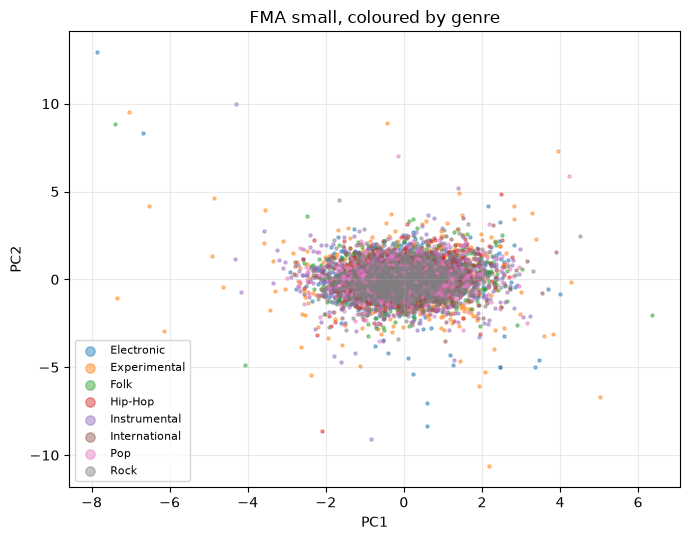

In [3]:
proj = PCA(n_components=2, random_state=0).fit_transform(X)
fig, ax = plt.subplots(figsize=(7, 5.5))
for g in sorted(np.unique(genres)):
    m = genres == g
    ax.scatter(proj[m, 0], proj[m, 1], s=5, alpha=0.45, label=g)
ax.set(xlabel="PC1", ylabel="PC2", title="FMA small, coloured by genre")
ax.legend(markerscale=3, fontsize=8, loc="best")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Genres overlap heavily — no clean boundaries.** Read alone this looks like failure.
It is not: album retrieval runs ~223x chance in the same space, so local neighbourhoods
are highly structured even though global genre regions are not.

That is the space the PRD wants. It asks for a system that explains where a track sits
*beyond* its genre label, and Bridge Finder needs to traverse between anchors without
genre walls blocking the path. Clean genre clusters would make bridging harder.

## 3. Do the label proxies actually separate distances?

Genre is coarse, album is tight. If the embedding is meaningful, same-album pairs should
sit closer than same-artist, which should sit closer than same-genre.

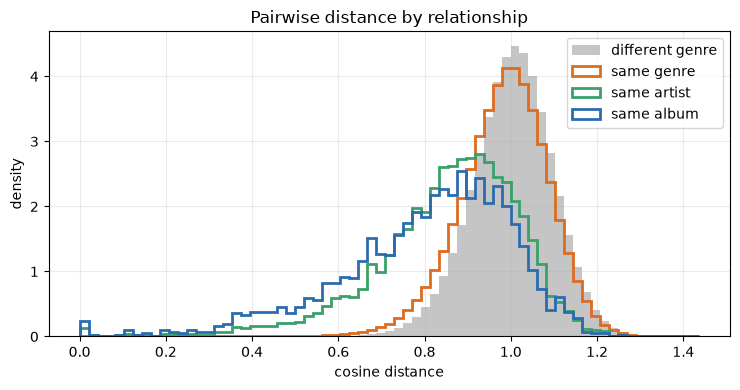

median distance, same genre  : 0.989   (n=390,636)
median distance, same artist : 0.877   (n=5,413)
median distance, same album  : 0.838   (n=2,034)
median distance, unrelated    : 1.006


In [4]:
from sklearn.metrics import pairwise_distances

rng = np.random.default_rng(0)
idx = rng.choice(len(X), 2500, replace=False)
D = pairwise_distances(X[idx], metric="cosine")
iu = np.triu_indices(len(idx), k=1)
d = D[iu]

pairs = {k: (labels[k][idx][iu[0]] == labels[k][idx][iu[1]]) for k in ("genre", "artist", "album")}

fig, ax = plt.subplots(figsize=(7.5, 4))
bins = np.linspace(0, d.max(), 70)
ax.hist(
    d[~pairs["genre"]], bins=bins, density=True, alpha=0.45, label="different genre", color="grey"
)
for key, colour in [("genre", "#dd6b20"), ("artist", "#38a169"), ("album", "#2b6cb0")]:
    ax.hist(
        d[pairs[key]],
        bins=bins,
        density=True,
        histtype="step",
        lw=2,
        label=f"same {key}",
        color=colour,
    )
ax.set(xlabel="cosine distance", ylabel="density", title="Pairwise distance by relationship")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

for k in ("genre", "artist", "album"):
    print(f"median distance, same {k:<7}: {np.median(d[pairs[k]]):.3f}   (n={pairs[k].sum():,})")
print(f"median distance, unrelated    : {np.median(d[~pairs['genre']]):.3f}")

**The ordering holds: album < artist < genre < unrelated.** The embedding encodes
production and session similarity most tightly, style next, and coarse genre last —
exactly the gradient a similarity model should show, and the reason album retrieval is
the more trustworthy metric to tune against.

## 4. Which genres does retrieval work for?

An aggregate P@5 hides per-genre variation, and coverage honesty (PRD principle 2)
depends on knowing where the model is weak.

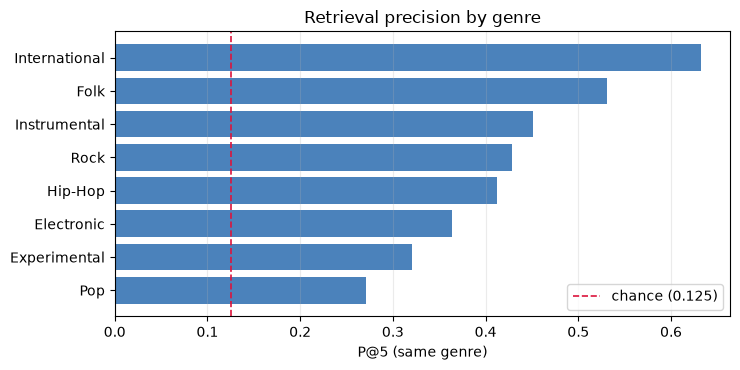

International          0.632
Folk                   0.531
Instrumental           0.451
Rock                   0.429
Hip-Hop                0.412
Electronic             0.364
Experimental           0.321
Pop                    0.271


In [5]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=6, metric="cosine").fit(X)
neigh = nn.kneighbors(X, return_distance=False)[:, 1:]
hit = (genres[neigh] == genres[:, None]).mean(axis=1)

order = sorted(np.unique(genres), key=lambda g: hit[genres == g].mean())
scores = [hit[genres == g].mean() for g in order]

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.barh(order, scores, color="#2b6cb0", alpha=0.85)
ax.axvline(1 / 8, ls="--", c="crimson", lw=1.2, label="chance (0.125)")
ax.set(xlabel="P@5 (same genre)", title="Retrieval precision by genre")
ax.legend()
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

for g, s in zip(reversed(order), reversed(scores)):
    print(f"{g:<22} {s:.3f}")

**Every genre beats chance, but the spread is wide.** Genres with a distinctive
sonic signature retrieve well; broad umbrella labels covering many production styles
retrieve worst — which is a fact about the *labels*, not a failure of the embedding.

This is what principle 2 requires us to surface: when Model C answers from a weak region
of the space, it should say so rather than present a confident match.

---

## Conclusions

1. Variance is front-loaded, so whitening is necessary — but only pays off under cosine.
2. Genres overlap; local neighbourhoods are still highly structured. Right shape for
   Bridge Finder.
3. Distances order album < artist < genre < unrelated, validating album retrieval as the
   metric to tune against.
4. Per-genre retrieval varies widely, so confidence must be reported per query.

Next: A4b (our own features from audio, compared against these) and A9 (AcousticBrainz,
the path to the real library). See `RESULTS.md` and `docs/track-a-acoustic.md`.